# 🏛️ Harvard's Artifacts Collection: ETL, SQL Analytics & Streamlit Showcase

End-to-end pipeline against the Harvard Art Museums public API:

1. **Extract** — fetch classifications & paginate through `/object` records
2. **Transform** — normalize the raw JSON into 3 tables
3. **Load** — create a SQLite database and insert the data
4. **Query** — run the 20 required analytical SQL queries + 6 bonus queries, with charts

> Run the cells top to bottom. Fill in your API key in the **Configuration** cell before running.

## 1. Setup

In [1]:
# Install only needed packages (skip if already installed)
!pip install requests pandas matplotlib pymysql sqlalchemy --quiet

import time
import pymysql
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
print("Imports ready.")


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports ready.


## 2. Configuration

Get a free API key at https://www.harvardartmuseums.org/collections/api ("Send a request").
Paste it below — **do not commit this notebook with your real key in it**.

In [2]:
API_KEY =  "8c647885-c2b1-4554-9be1-7d8937e6ff53"          # <-- put your key here
CLASSIFICATION_URL = "https://api.harvardartmuseums.org/classification"
OBJECT_URL = "https://api.harvardartmuseums.org/object"

CHOSEN_CLASSIFICATION = "Paintings"           # e.g. Paintings, Sculpture, Coins, Jewelry, Drawings...
TARGET_COUNT = 2500                           # minimum 2500 records per the project spec
PAGE_SIZE = 100

# ---- MySQL connection settings ----
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_USER = "root"
MYSQL_PASSWORD = "root"
MYSQL_DB = "harvard_artifacts"

OBJECT_FIELDS = [
    "id", "title", "culture", "period", "century", "medium", "dimensions",
    "description", "department", "classification", "accessionyear",
    "accessionmethod", "images", "colors", "rank", "objectnumber",
    "datebegin", "dateend", "mediacount", "imagecount", "colorcount", "dated",
]

print("Classification:", CHOSEN_CLASSIFICATION, "| Target records:", TARGET_COUNT)

Classification: Paintings | Target records: 2500


## 3. Extract — Available Classifications

Quick sanity check on the API key + a look at what classifications exist (116 total per the museum's archive).

In [3]:
resp = requests.get(CLASSIFICATION_URL, params={"apikey": API_KEY, "size": 100})
resp.raise_for_status()
class_records = resp.json().get("records", [])

df_classifications = pd.DataFrame(class_records)[["id", "name", "objectcount"]].sort_values("name")
print(f"Fetched {len(df_classifications)} classifications (showing first page).")
display(df_classifications.head(20))

Fetched 63 classifications (showing first page).


,id,name,objectcount
3,0,(not assigned),355
14,2,Accessories (non-art),2809
56,384,Albums,538
46,180,Amulets,134
40,133,Architectural Elements,1176
29,64,Archival Material,16250
49,242,Armor,57
58,1012,Artists' Materials,655
37,97,Artists' Tools,1615
30,71,Audiovisual Works,438


## 4. Extract — Fetch Object Records (Paginated)

Pages through `/object` for `CHOSEN_CLASSIFICATION` until `TARGET_COUNT` records are collected.

In [4]:
def fetch_objects(api_key, classification, target_count, page_size=100):
    fetched = []
    page = 1
    while len(fetched) < target_count:
        params = {
            "apikey": api_key,
            "classification": classification,
            "size": page_size,
            "page": page,
            "fields": ",".join(OBJECT_FIELDS),
        }
        r = requests.get(OBJECT_URL, params=params)
        if r.status_code != 200:
            print("API returned status", r.status_code, "- stopping fetch")
            break

        payload = r.json()
        records = payload.get("records", [])
        if not records:
            break

        fetched.extend(records)
        page += 1
        print(f"  fetched {len(fetched)} / {target_count}...", end="\r")

        info = payload.get("info", {})
        if info.get("pages") and page > info["pages"]:
            break
        time.sleep(0.15)  # be polite to the API

    return fetched[:target_count]


fetched_records = fetch_objects(API_KEY, CHOSEN_CLASSIFICATION, TARGET_COUNT, PAGE_SIZE)
print(f"\nTotal fetched: {len(fetched_records)}")

  fetched 2500 / 2500...
Total fetched: 2500


In [5]:
# Save a raw copy for inspection / reproducibility
import json as _json
with open("harvard_fetched.json", "w", encoding="utf-8") as f:
    _json.dump(fetched_records, f, ensure_ascii=False, indent=2)
print("Saved harvard_fetched.json")

Saved harvard_fetched.json


## 5. Transform — Normalize into 3 Tables

Splits each raw record into rows for `artifact_metadata`, `artifact_media`, and `artifact_colors`.

In [6]:
def transform_records(records):
    metadata_rows, media_rows, colors_rows = [], [], []

    for rec in records:
        obj_id = rec.get("id") or rec.get("objectnumber")

        metadata_rows.append({
            "id": obj_id,
            "title": rec.get("title"),
            "culture": rec.get("culture"),
            "period": rec.get("period"),
            "century": rec.get("century") or rec.get("dated"),
            "medium": rec.get("medium"),
            "dimensions": rec.get("dimensions"),
            "description": rec.get("description"),
            "department": rec.get("department"),
            "classification": rec.get("classification"),
            "accessionyear": rec.get("accessionyear"),
            "accessionmethod": rec.get("accessionmethod"),
        })

        imagecount = rec.get("imagecount")
        if imagecount is None:
            imagecount = len(rec.get("images") or [])

        media_rows.append({
            "objectid": obj_id,
            "imagecount": imagecount,
            "mediacount": rec.get("mediacount"),
            "colorcount": rec.get("colorcount"),
            "rank": rec.get("rank"),
            "datebegin": rec.get("datebegin"),
            "dateend": rec.get("dateend"),
        })

        for c in (rec.get("colors") or []):
            colors_rows.append({
                "objectid": obj_id,
                "color": c.get("color"),
                "spectrum": c.get("spectrum"),
                "hue": c.get("hue"),
                "percent": c.get("percent"),
                "css3": c.get("css3"),
            })

    df_metadata = pd.DataFrame(metadata_rows).drop_duplicates(subset="id")
    df_media = pd.DataFrame(media_rows).drop_duplicates(subset="objectid")
    df_colors = pd.DataFrame(colors_rows)
    return df_metadata, df_media, df_colors


df_metadata, df_media, df_colors = transform_records(fetched_records)
print("Transformed counts -> metadata:", len(df_metadata),
      "| media:", len(df_media), "| colors:", len(df_colors))

Transformed counts -> metadata: 2500 | media: 2500 | colors: 18529


In [7]:
print("artifact_metadata sample:")
display(df_metadata.head(3))
print("\nartifact_media sample:")
display(df_media.head(3))
print("\nartifact_colors sample:")
display(df_colors.head(3))

artifact_metadata sample:


,id,title,culture,period,century,medium,dimensions,description,department,classification,accessionyear,accessionmethod
0,1429,What a Glorious Land!,Chinese,None,21st century,Handscroll; ink on paper; with signature in cl...,"entire painting, including title: H. 17 x W. 3...",This handscroll depicts a range of tree-covere...,Department of Asian Art,Paintings,2006.0,Purchase
1,4586,"Streams and Mountains, from the series ""Sacrif...",Chinese,None,21st century,One from a set of twenty-four album leaves; in...,41.7 x 24.1 cm (16 7/16 x 9 1/2 in.),None,Department of Asian Art,Paintings,2006.0,Purchase
2,4615,"The Great Wall Snaking through the Mountains, ...",Chinese,None,21st century,One from a set of twenty-four album leaves; in...,41.8 x 24.1 cm (16 7/16 x 9 1/2 in.),None,Department of Asian Art,Paintings,2006.0,Purchase



artifact_media sample:


,objectid,imagecount,mediacount,colorcount,rank,datebegin,dateend
0,1429,27,0,7,126410,2005,2005
1,4586,2,0,9,126422,2005,2005
2,4615,1,0,9,126431,2005,2005



artifact_colors sample:


,objectid,color,spectrum,hue,percent,css3
0,1429,#7d7d7d,#8362aa,Grey,0.251473,#808080
1,1429,#c8c8c8,#8c5fa8,Grey,0.182791,#c0c0c0
2,1429,#646464,#7866ad,Grey,0.178450,#696969


## 6. Load — Create SQLite Tables & Insert Data

In [8]:
!pip install cryptography --quiet
print("cryptography installed.")

cryptography installed.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306          # or whatever port you're using
MYSQL_USER = "root"
MYSQL_PASSWORD = "root"
MYSQL_DB = "harvard_artifacts" # set this to your actual database name

# Connect to MySQL server (no DB selected yet) and create the database if needed
bootstrap_conn = pymysql.connect(
    host=MYSQL_HOST, port=MYSQL_PORT, user=MYSQL_USER, password=MYSQL_PASSWORD, autocommit=True
)
with bootstrap_conn.cursor() as bcur:
    bcur.execute(f"CREATE DATABASE IF NOT EXISTS `{MYSQL_DB}` CHARACTER SET utf8mb4;")
bootstrap_conn.close()

# Now connect to the target database for the rest of the notebook
conn = pymysql.connect(
    host=MYSQL_HOST, port=MYSQL_PORT, user=MYSQL_USER, password=MYSQL_PASSWORD,
    database=MYSQL_DB, autocommit=False, charset="utf8mb4"
)
cur = conn.cursor()

# SQLAlchemy engine, used only for pd.read_sql_query (pandas needs this, not a raw DBAPI conn)
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}"
)

In [10]:
ddl_statements = [
    """
    CREATE TABLE IF NOT EXISTS artifact_metadata (
        id              INT PRIMARY KEY,
        title           TEXT,
        culture         VARCHAR(255),
        period          VARCHAR(255),
        century         VARCHAR(255),
        medium          TEXT,
        dimensions      VARCHAR(255),
        description     TEXT,
        department      VARCHAR(255),
        classification  VARCHAR(255),
        accessionyear   INT,
        accessionmethod VARCHAR(255)
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS artifact_media (
        objectid   INT PRIMARY KEY,
        imagecount INT,
        mediacount INT,
        colorcount INT,
        `rank`     INT,
        datebegin  INT,
        dateend    INT,
        FOREIGN KEY (objectid) REFERENCES artifact_metadata(id)
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS artifact_colors (
        color_id  INT AUTO_INCREMENT PRIMARY KEY,
        objectid  INT,
        color     VARCHAR(50),
        spectrum  VARCHAR(50),
        hue       VARCHAR(50),
        percent   FLOAT,
        css3      VARCHAR(50),
        FOREIGN KEY (objectid) REFERENCES artifact_metadata(id)
    );
    """,
]

for stmt in ddl_statements:
    cur.execute(stmt)
conn.commit()
print("Tables created (or already existed).")

Tables created (or already existed).


In [11]:
import numpy as np

def df_to_records(df, cols):
    """Convert a DataFrame's selected columns into a list of tuples that
    pymysql can safely insert: NaN/NaT -> None, whole-number floats -> int
    (so INT columns don't receive values like 2011.0)."""
    sub = df[cols].astype(object)
    sub = sub.where(pd.notnull(sub), None)
    records = []
    for row in sub.itertuples(index=False, name=None):
        clean = []
        for v in row:
            if isinstance(v, float) and v.is_integer():
                v = int(v)
            clean.append(v)
        records.append(tuple(clean))
    return records


# Insert metadata
metadata_cols = ["id","title","culture","period","century","medium","dimensions",
                  "description","department","classification","accessionyear","accessionmethod"]
cur.executemany("""
    REPLACE INTO artifact_metadata
    (id,title,culture,period,century,medium,dimensions,description,department,classification,accessionyear,accessionmethod)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
""", df_to_records(df_metadata, metadata_cols))

# Insert media
media_cols = ["objectid","imagecount","mediacount","colorcount","rank","datebegin","dateend"]
cur.executemany("""
    REPLACE INTO artifact_media
    (objectid,imagecount,mediacount,colorcount,`rank`,datebegin,dateend)
    VALUES (%s,%s,%s,%s,%s,%s,%s)
""", df_to_records(df_media, media_cols))

# Insert colors
if not df_colors.empty:
    colors_cols = ["objectid","color","spectrum","hue","percent","css3"]
    cur.executemany("""
        INSERT INTO artifact_colors (objectid,color,spectrum,hue,percent,css3)
        VALUES (%s,%s,%s,%s,%s,%s)
    """, df_to_records(df_colors, colors_cols))

conn.commit()
print("Inserted rows -> metadata:", len(df_metadata), "| media:", len(df_media), "| colors:", len(df_colors))

Inserted rows -> metadata: 2500 | media: 2500 | colors: 18529


In [12]:
def run_sql(query):
    return pd.read_sql_query(query, engine)

print("Row counts in DB:")
for t in ["artifact_metadata", "artifact_media", "artifact_colors"]:
    print(f"  {t}: {run_sql(f'SELECT COUNT(*) AS cnt FROM {t}')['cnt'].iloc[0]}")

Row counts in DB:
  artifact_metadata: 2500
  artifact_media: 2500
  artifact_colors: 18529


## 7. SQL Queries & Visualization

In [13]:
def show_result(df, chart_col=None, title=None, top_n=15):
    """Display a query result as a table, and optionally as a bar chart
    when it has a clear category/value shape."""
    display(df)
    if chart_col and not df.empty and chart_col in df.columns:
        cat_col = [c for c in df.columns if c != chart_col][0]
        plot_df = df.dropna(subset=[cat_col, chart_col]).head(top_n)
        if not plot_df.empty:
            plt.figure(figsize=(8, 4))
            plt.bar(plot_df[cat_col].astype(str), plot_df[chart_col])
            plt.xticks(rotation=60, ha="right")
            plt.ylabel(chart_col)
            plt.title(title or f"{chart_col} by {cat_col}")
            plt.tight_layout()
            plt.show()

### 🏺 artifact_metadata queries

**Q2. Unique cultures represented**

In [15]:
result = run_sql("""SELECT DISTINCT culture FROM artifact_metadata
WHERE culture IS NOT NULL ORDER BY culture;""")
show_result(result)

,culture
0,American
1,American?
2,Austrian
3,Belgian
4,British
5,Burmese
6,Byzantine
7,Canadian
8,Central Asian
9,Chinese


**Q4. Artifact titles ordered by accession year (desc)**

In [17]:
result = run_sql("""SELECT title, accessionyear FROM artifact_metadata
WHERE accessionyear IS NOT NULL
ORDER BY accessionyear DESC;""")
show_result(result)

,title,accessionyear
0,Looking West: Otoe-Missouria Figure on Horseback,2025
1,"[Na-ta-ga-sta-ga (Eagle Feathers)], Pawnee Sc...",2025
2,"Sarah Neptune, known as Sarah Molasses",2024
3,Two Human Beings (The Lonely Ones),2023
4,Francophone Women of Color and a Young Attenda...,2023
...,...,...
2379,The Virgin of the Annunciation,1914
2380,Portrait of Emperor William II of Germany,1909
2381,Joos van der Burch and Saint Simon of Jerusalem,1906
2382,Two Evangelists,1895


**Q5. Artifact count per department**

,department,artifact_count
0,Department of Asian Art,1662
1,Busch-Reisinger Museum,194
2,"Department of Paintings, Sculpture & Decorativ...",178
3,Department of Modern & Contemporary Art,155
4,Department of Islamic & Later Indian Art,113
5,Harvard University Portrait Collection,111
6,"Department of American Paintings, Sculpture & ...",82
7,Department of Ancient and Byzantine Art & Numi...,3
8,Straus Center for Conservation and Technical S...,2


C:\Users\Dipika\AppData\Local\Temp\ipykernel_8760\2614742481.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


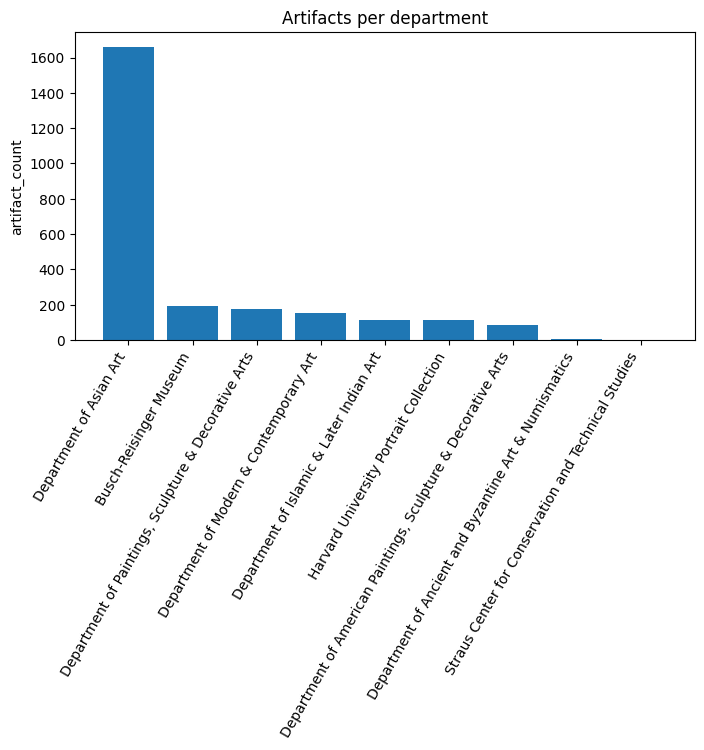

In [18]:
result = run_sql("""SELECT department, COUNT(*) AS artifact_count
FROM artifact_metadata
GROUP BY department
ORDER BY artifact_count DESC;""")
show_result(result, chart_col="artifact_count", title="Artifacts per department")

### 🖼️ artifact_media queries

**Q6. Artifacts with more than 1 image**

In [19]:
result = run_sql("""SELECT md.id, md.title, m.imagecount
FROM artifact_media m
JOIN artifact_metadata md ON md.id = m.objectid
WHERE m.imagecount > 1;""")
show_result(result)

,id,title,imagecount
0,1429,What a Glorious Land!,27
1,4586,"Streams and Mountains, from the series ""Sacrif...",2
2,4927,Landscape with Full Moon,2
3,5109,Landscape,2
4,5145,"A Thousand Peaks and Myriad Ravines, from the ...",2
...,...,...,...
804,227653,Grotto on the Italian Coast,3
805,227666,Portrait of an Old Man,3
806,227696,Dead Christ,2
807,227716,Forest Landscape,2


**Q7. Average rank of all artifacts**

In [20]:
result = run_sql("""SELECT AVG(`rank`) AS average_rank FROM artifact_media;""")
show_result(result)

,average_rank
0,106419.4328


**Q8. Artifacts with colorcount > mediacount**

In [21]:
result = run_sql("""SELECT md.id, md.title, m.colorcount, m.mediacount
FROM artifact_media m
JOIN artifact_metadata md ON md.id = m.objectid
WHERE m.colorcount > m.mediacount;""")
show_result(result)

,id,title,colorcount,mediacount
0,1429,What a Glorious Land!,7,0
1,4586,"Streams and Mountains, from the series ""Sacrif...",9,0
2,4615,"The Great Wall Snaking through the Mountains, ...",9,0
3,4640,"Fantastic Mountains in Western China, from the...",9,0
4,4728,Ida B. Wells (1862-1931),10,0
...,...,...,...,...
2321,227696,Dead Christ,10,0
2322,227716,Forest Landscape,7,0
2323,227734,Seated Woman,5,0
2324,227737,Original Face,7,0


**Q9. Artifacts created between 1500 and 1600**

In [22]:
result = run_sql("""SELECT md.id, md.title, m.datebegin, m.dateend
FROM artifact_media m
JOIN artifact_metadata md ON md.id = m.objectid
WHERE m.datebegin >= 1500 AND m.dateend <= 1600;""")
show_result(result)

,id,title,datebegin,dateend
0,78048,Landscape after Huang Gongwang and Ni Zan,1599,1599
1,174915,Allegorical Portrait of a Young Man in the Gui...,1575,1580
2,178579,"Virgin and Child with Saints Sebastian, Franci...",1510,1520
3,189098,A Gathering of Scholars in a Garden ('Touhu tu'),1550,1599
4,193914,Christ in the Garden of Gethsemane,1515,1525
...,...,...,...,...
99,227510,Portrait of a Man,1533,1566
100,227525,Saint Sebastian,1590,1595
101,227550,The Holy Family with Saint Jerome,1545,1555
102,227571,Holy Family with the Young Baptist and an Angel,1505,1515


**Q10. Artifacts with no media files**

In [23]:
result = run_sql("""SELECT COUNT(*) AS no_media_count
FROM artifact_media
WHERE mediacount IS NULL OR mediacount = 0;""")
show_result(result)

,no_media_count
0,2496


### 🎨 artifact_colors queries

**Q11. Distinct hues in the dataset**

In [24]:
result = run_sql("""SELECT DISTINCT hue FROM artifact_colors
WHERE hue IS NOT NULL ORDER BY hue;""")
show_result(result)

,hue
0,Black
1,Blue
2,Brown
3,Green
4,Grey
5,Orange
6,Red
7,Violet
8,White
9,Yellow


**Q12. Top 5 most used colors by frequency**

,color,frequency
0,#323232,786
1,#4b4b4b,720
2,#646464,637
3,#7d7d7d,621
4,#969696,601


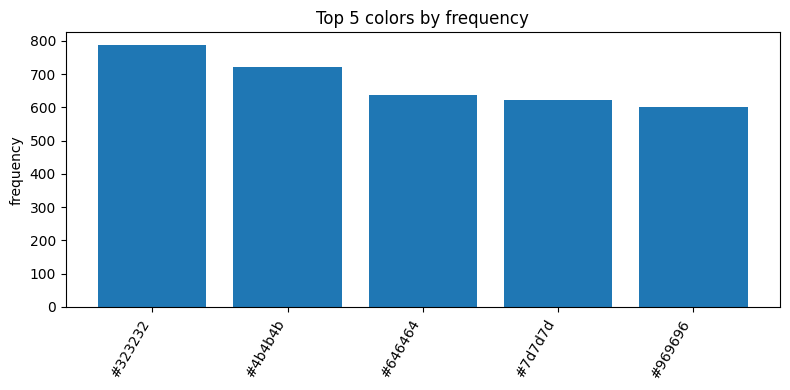

In [25]:
result = run_sql("""SELECT color, COUNT(*) AS frequency
FROM artifact_colors
WHERE color IS NOT NULL
GROUP BY color
ORDER BY frequency DESC
LIMIT 5;""")
show_result(result, chart_col="frequency", title="Top 5 colors by frequency")

**Q13. Average coverage percentage per hue**

,hue,avg_percent
0,Orange,0.170210
1,Yellow,0.143193
2,Brown,0.136761
3,Green,0.123488
4,Black,0.122587
5,Grey,0.113058
6,White,0.103592
7,Violet,0.095951
8,Red,0.087294
9,Blue,0.070053


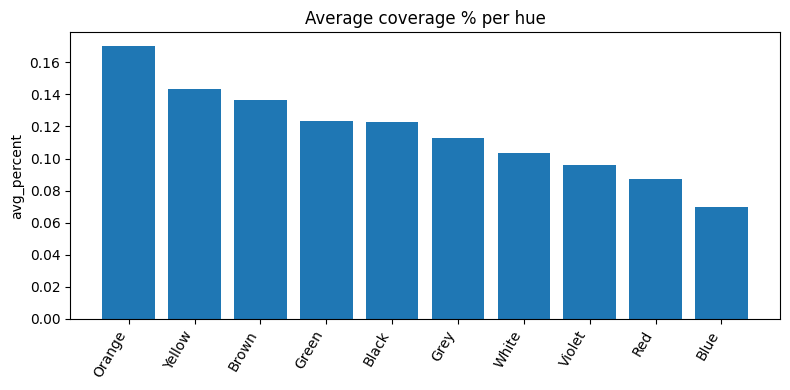

In [26]:
result = run_sql("""SELECT hue, AVG(percent) AS avg_percent
FROM artifact_colors
WHERE hue IS NOT NULL
GROUP BY hue
ORDER BY avg_percent DESC;""")
show_result(result, chart_col="avg_percent", title="Average coverage % per hue")

**Q14. Colors used for a given artifact ID**

In [27]:
OBJECT_ID = df_metadata["id"].iloc[0] if not df_metadata.empty else 1  # <-- change to any artifact ID
result = run_sql(f"SELECT * FROM artifact_colors WHERE objectid = {OBJECT_ID};")
show_result(result)

,color_id,objectid,color,spectrum,hue,percent,css3
0,1,1429,#7d7d7d,#8362aa,Grey,0.251473,#808080
1,2,1429,#c8c8c8,#8c5fa8,Grey,0.182791,#c0c0c0
2,3,1429,#646464,#7866ad,Grey,0.178450,#696969
3,4,1429,#afafaf,#8c5fa8,Grey,0.171628,#a9a9a9
4,5,1429,#969696,#8761aa,Grey,0.163876,#a9a9a9
5,6,1429,#4b4b4b,#3db657,Grey,0.026977,#2f4f4f
6,7,1429,#e1e1e1,#955ba5,Grey,0.024806,#dcdcdc


**Q15. Total number of color entries**

In [28]:
result = run_sql("""SELECT COUNT(*) AS total_color_entries FROM artifact_colors;""")
show_result(result)

,total_color_entries
0,18529


### 🔗 Join-Based queries

**Q16. Titles and hues for Byzantine culture artifacts**

In [29]:
result = run_sql("""SELECT md.title, c.hue
FROM artifact_metadata md
JOIN artifact_colors c ON c.objectid = md.id
WHERE md.culture = 'Byzantine';""")
show_result(result)

,title,hue
0,Saint Andrew and Scenes from his Life,Yellow
1,Saint Andrew and Scenes from his Life,Yellow
2,Saint Andrew and Scenes from his Life,Brown
3,Saint Andrew and Scenes from his Life,Brown
4,Saint Andrew and Scenes from his Life,Brown
5,Saint Andrew and Scenes from his Life,Brown
6,Saint Andrew and Scenes from his Life,Brown
7,Saint Andrew and Scenes from his Life,Brown
8,Saint Andrew and Scenes from his Life,Green
9,Saint Andrew and Scenes from his Life,Orange


**Q17. Each artifact title with its associated hues**

In [30]:
result = run_sql("""SELECT md.title, GROUP_CONCAT(DISTINCT c.hue) AS hues
FROM artifact_metadata md
JOIN artifact_colors c ON c.objectid = md.id
GROUP BY md.title;""")
show_result(result)

,title,hues
0,"""Lief om Leet"" (""Love Leads to Suffering"")","Black,Brown,Green,Orange"
1,"""One-Finger Zen"" of Monk Chü-chih","Brown,Grey,Red,Yellow"
2,"""Poems of Spring"" (Tosa School)","Black,Grey,White"
3,“Bhusti”,"Brown,Green,Grey,Orange,Yellow"
4,“Chuprassi”,"Green,Grey,Red,Yellow"
...,...,...
1932,Yusuf and Zulaykha,"Blue,Brown,Green,Orange,Yellow"
1933,Z VI,"Brown,Green,Grey,Orange,Red"
1934,Zaccheus in the Tree,"Black,Grey,White"
1935,Zhang Guo and his Magical Gourd,"Brown,Grey,Yellow"


**Q18. Titles, cultures, media ranks where period is not null**

In [31]:
result = run_sql("""SELECT md.title, md.culture, m.`rank`
FROM artifact_metadata md
JOIN artifact_media m ON m.objectid = md.id
WHERE md.period IS NOT NULL;""")
show_result(result)

,title,culture,rank
0,Landscape with Full Moon,Japanese,125118
1,Landscape,Korean,126169
2,Sixteen Arhats (Rakan) in a Fantastic Landscape,Japanese,125547
3,Orchids and Rocks,Korean,125793
4,Orchids and Rocks,Korean,125795
...,...,...,...
1427,Tibetan Yak with Vignettes of Animals,Mughal,121500
1428,Wounded Buck with Vignettes of Animals,Mughal,121501
1429,Fruiting Grape Branch,Korean,116124
1430,Fruiting Grape Branch,Korean,116125


**Q19. Top-10-ranked artifacts that include hue 'Grey'**

In [32]:
result = run_sql("""SELECT DISTINCT md.title, m.`rank`
FROM artifact_metadata md
JOIN artifact_media m ON m.objectid = md.id
JOIN artifact_colors c ON c.objectid = md.id
WHERE c.hue = 'Grey'
ORDER BY m.`rank` ASC
LIMIT 10;""")
show_result(result)

,title,rank
0,Soul History,105
1,"Study for ""Prometheus,"" Museum of Fine Arts, B...",170
2,Still Life with Watermelon,185
3,Six Legendary Chinese Sages in Landscapes,201
4,Joos van der Burch and Saint Simon of Jerusalem,223
5,Two Human Beings (The Lonely Ones),326
6,The Message,352
7,Power of Death,386
8,Ink Landscape,408
9,The Miraculous Translation of the Body of Sain...,412


**Q20. Artifact count & avg media count per classification**

,classification,artifact_count,avg_mediacount
0,Paintings,2500,0.0016


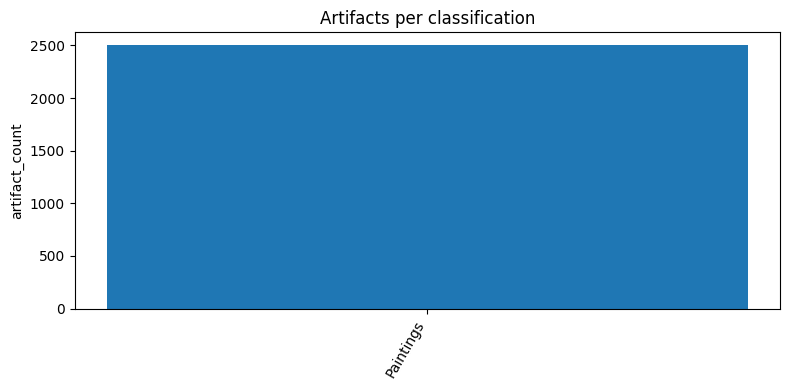

In [33]:
result = run_sql("""SELECT md.classification,
       COUNT(DISTINCT md.id) AS artifact_count,
       AVG(m.mediacount) AS avg_mediacount
FROM artifact_metadata md
JOIN artifact_media m ON m.objectid = md.id
GROUP BY md.classification
ORDER BY artifact_count DESC;""")
show_result(result, chart_col="artifact_count", title="Artifacts per classification")

### ⭐ Bonus / Custom queries

**B1. Top 10 mediums by artifact count**

,medium,artifact_count
0,Oil on canvas,411
1,Album leaf; ink and color on paper,68
2,Album; ink on paper,56
3,Oil on panel,56
4,"Album leaf; ink, color, and gold on silk",54
5,One of fifty-four paintings (originally fifty-...,54
6,Hanging scroll; ink on paper,45
7,Sketch pasted into an accordion fold book; ink...,40
8,Hanging scroll; ink and color on silk,31
9,Album leaf; ink and color on silk,30


C:\Users\Dipika\AppData\Local\Temp\ipykernel_8760\2614742481.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


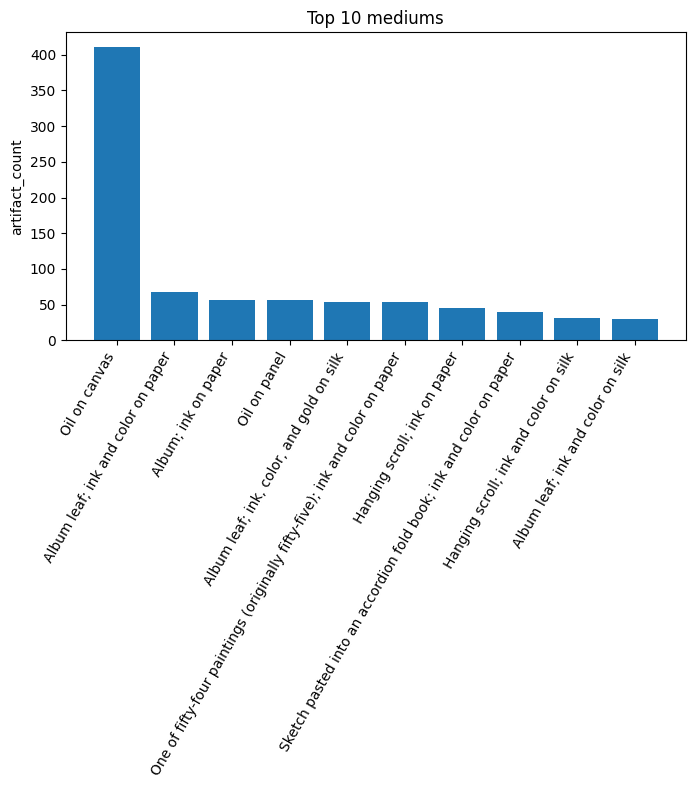

In [34]:
result = run_sql("""SELECT medium, COUNT(*) AS artifact_count
FROM artifact_metadata
WHERE medium IS NOT NULL
GROUP BY medium
ORDER BY artifact_count DESC
LIMIT 10;""")
show_result(result, chart_col="artifact_count", title="Top 10 mediums")

**B2. Artifacts per century**

,century,artifact_count
0,20th century,556
1,19th century,440
2,17th century,319
3,18th century,267
4,16th century,138
5,18th-19th century,99
6,19th-20th century,89
7,21st century,51
8,17th-18th century,48
9,15th century,38


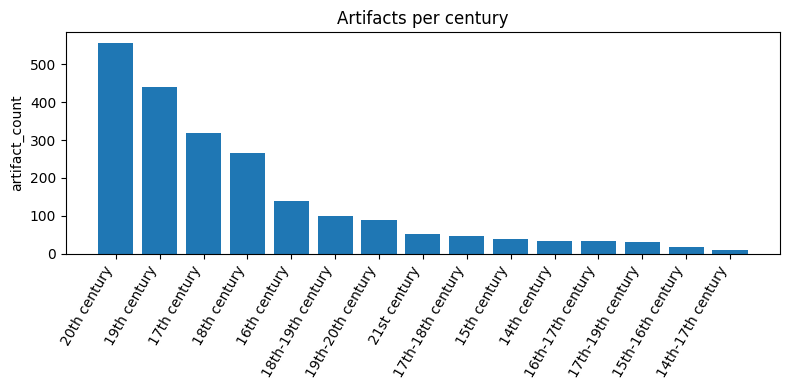

In [35]:
result = run_sql("""SELECT century, COUNT(*) AS artifact_count
FROM artifact_metadata
WHERE century IS NOT NULL
GROUP BY century
ORDER BY artifact_count DESC;""")
show_result(result, chart_col="artifact_count", title="Artifacts per century")

**B3. Top 10 accession methods used**

,accessionmethod,artifact_count
0,Gift,1155
1,Bequest,809
2,Purchase,389
3,Not Recorded,116
4,Transfer,19
5,Partial Gift/Partial Purchase,5
6,Found in Collection,4
7,Unidentified,2
8,Commission,1


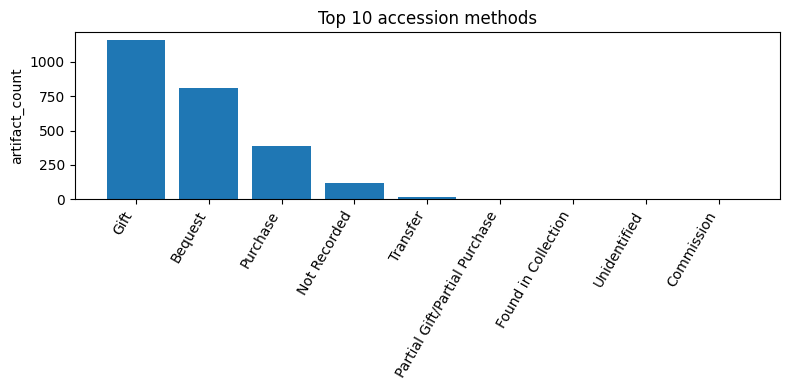

In [36]:
result = run_sql("""SELECT accessionmethod, COUNT(*) AS artifact_count
FROM artifact_metadata
WHERE accessionmethod IS NOT NULL
GROUP BY accessionmethod
ORDER BY artifact_count DESC
LIMIT 10;""")
show_result(result, chart_col="artifact_count", title="Top 10 accession methods")

**B4. Average image count per department**

,department,avg_imagecount
0,Department of Asian Art,2.1089
1,"Department of Paintings, Sculpture & Decorativ...",1.5393
2,Busch-Reisinger Museum,1.3093
3,"Department of American Paintings, Sculpture & ...",1.2927
4,Harvard University Portrait Collection,1.1622
5,Department of Islamic & Later Indian Art,1.1239
6,Department of Modern & Contemporary Art,1.0968
7,Department of Ancient and Byzantine Art & Numi...,1.0000
8,Straus Center for Conservation and Technical S...,0.5000


C:\Users\Dipika\AppData\Local\Temp\ipykernel_8760\2614742481.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


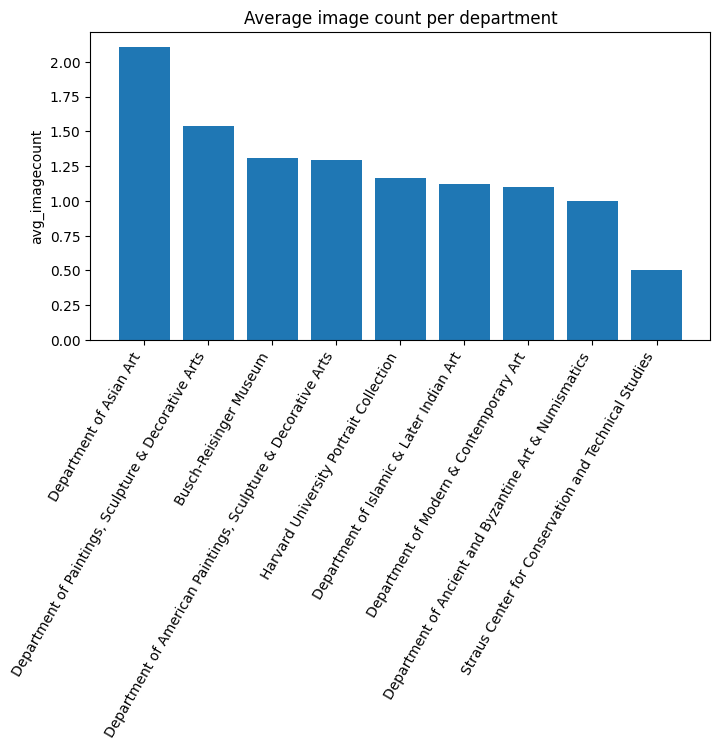

In [37]:
result = run_sql("""SELECT md.department, AVG(m.imagecount) AS avg_imagecount
FROM artifact_metadata md
JOIN artifact_media m ON m.objectid = md.id
GROUP BY md.department
ORDER BY avg_imagecount DESC;""")
show_result(result, chart_col="avg_imagecount", title="Average image count per department")

**B5. Artifacts with the widest date range (dateend - datebegin)**

In [38]:
result = run_sql("""SELECT md.title, m.datebegin, m.dateend,
       (m.dateend - m.datebegin) AS span_years
FROM artifact_metadata md
JOIN artifact_media m ON m.objectid = md.id
WHERE m.datebegin IS NOT NULL AND m.dateend IS NOT NULL
ORDER BY span_years DESC
LIMIT 10;""")
show_result(result)

,title,datebegin,dateend,span_years
0,Autumn Landscape,19,1932,1913
1,Landscape,18,1832,1814
2,"Twenty Scenes of Birds, Animals, Flowers and F...",17,1799,1782
3,Travelers in Mist and Rain,1600,1916,316
4,"Workers Grinding and Sieving, Likely Grinding ...",1600,1900,300
5,Rock and Vine with Green Leaves,1600,1899,299
6,Hotei,1632,1916,284
7,Fighting Mynah Birds,1368,1644,276
8,"PAIR OF CHINESE PHEASANTS, TREE PEONY ETC.",1368,1644,276
9,"Scholar, Attendant, and Crane",1368,1644,276


**B6. Most common CSS3 color overall**

,css3,frequency
0,#2f4f4f,2074
1,#696969,2067
2,#808080,1997
3,#a9a9a9,1545
4,#000000,1305
5,#c0c0c0,967
6,#d2b48c,864
7,#556b2f,856
8,#dcdcdc,845
9,#bc8f8f,756


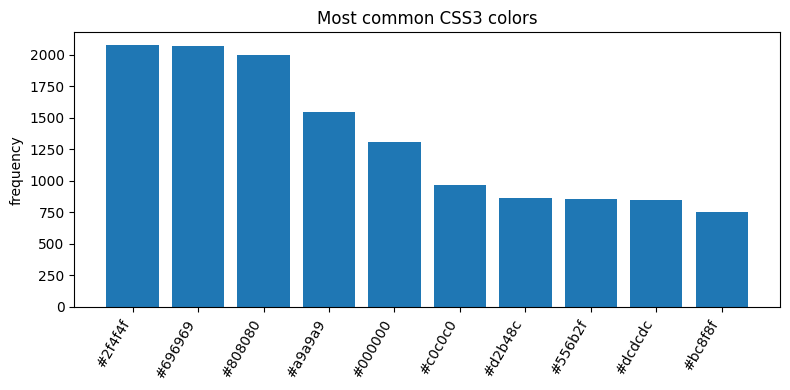

In [39]:
result = run_sql("""SELECT css3, COUNT(*) AS frequency
FROM artifact_colors
WHERE css3 IS NOT NULL
GROUP BY css3
ORDER BY frequency DESC
LIMIT 10;""")
show_result(result, chart_col="frequency", title="Most common CSS3 colors")

## 8. Done

The MySQL database `harvard_artifacts` now contains the 3 populated tables. Re-run **Section 2–6** with a
different `CHOSEN_CLASSIFICATION` to add another category's data (upserted by
default), then re-run any query cell above.

In [40]:
conn.close()
engine.dispose()
print("Connection closed. Data is saved in the MySQL database '" + MYSQL_DB + "'.")

Connection closed. Data is saved in the MySQL database 'harvard_artifacts'.
